<a href="https://colab.research.google.com/github/Gabriel-Arsego/Garsego_64061/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 2** - Convolution

Adding zipfile

In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('cats_vs_dogs_small.zip', 'r')
zip_ref.extractall()
zip_ref.close()

In [ ]:
import pathlib

base_dir = pathlib.Path("cats_vs_dogs_small")

Using code provided by the Professor

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    base_dir / "train",
    image_size=(180, 180),
    batch_size=32
)

validation_dataset = image_dataset_from_directory(
    base_dir / "validation",
    image_size=(180, 180),
    batch_size=32
)

test_dataset = image_dataset_from_directory(
    base_dir / "test",
    image_size=(180, 180),
    batch_size=32
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
# EXPERIMENT SETUP

def subset_dataset(dataset, num_samples):
    dataset = dataset.unbatch()
    dataset = dataset.shuffle(10000, seed=42)
    dataset = dataset.take(num_samples)
    dataset = dataset.batch(32)
    return dataset

#Starting with 1000 total (500 each class)
train_small = subset_dataset(train_dataset, 1000)
train_medium = subset_dataset(train_dataset, 2000)
train_large = subset_dataset(train_dataset, 3000)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def build_scratch_model():
    inputs = keras.Input(shape=(180, 180, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Conv2D(32, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(256, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        loss="binary_crossentropy",
        optimizer="rmsprop",
        metrics=["accuracy"]
    )
    return model

In [ ]:
def run_experiment(model_builder, dataset, name, epochs):
    print("\nRunning:", name)
    model = model_builder()
    model.fit(dataset, epochs=20, validation_data=validation_dataset)
    loss, acc = model.evaluate(test_dataset)
    print("Test Accuracy:", acc)
    return acc

results = {}

results["Scratch_1000"] = run_experiment(build_scratch_model, train_small, "Scratch 1000", 20)
results["Scratch_2000"] = run_experiment(build_scratch_model, train_medium, "Scratch 2000", 20)
results["Scratch_3000"] = run_experiment(build_scratch_model, train_large, "Scratch 3000", 20)


Running: Scratch 1000
Epoch 1/20
     32/Unknown 12s 131ms/step - accuracy: 0.4899 - loss: 0.7600

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 219ms/step - accuracy: 0.5200 - loss: 0.7154 - val_accuracy: 0.5100 - val_loss: 0.6936
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.5660 - loss: 0.6887 - val_accuracy: 0.5000 - val_loss: 0.7558
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.5410 - loss: 0.6877 - val_accuracy: 0.5760 - val_loss: 0.6582
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.6100 - loss: 0.6640 - val_accuracy: 0.5960 - val_loss: 0.7152
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6390 - loss: 0.6659 - val_accuracy: 0.5630 - val_loss: 0.7238
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6670 - loss: 0.6144 - val_accuracy: 0.5740 - val_loss: 0.8454
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.6750 - loss: 0.6248 - val_accuracy: 0.6100 - val_loss: 0.6787
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6830 - loss: 0.6036 - val_accuracy: 0.6420 - val_los

In [ ]:
from tensorflow.keras.applications import VGG16

def build_pretrained_model():
    conv_base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(180,180,3)
    )

    conv_base.trainable = False

    inputs = keras.Input(shape=(180,180,3))
    x = conv_base(inputs)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.Adam(1e-4),
        metrics=['accuracy']
    )
    return model

In [ ]:
results["Pretrained_1000"] = run_experiment(build_pretrained_model, train_small, "Pretrained 1000", 10)
results["Pretrained_2000"] = run_experiment(build_pretrained_model, train_medium, "Pretrained 2000", 10)
results["Pretrained_3000"] = run_experiment(build_pretrained_model, train_large, "Pretrained 3000", 10)

print("\nFINAL RESULTS:")
for k,v in results.items():
    print(k, ":", v)


Running: Pretrained 1000
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 569ms/step - accuracy: 0.8460 - loss: 2.8516 - val_accuracy: 0.9300 - val_loss: 0.9112
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 284ms/step - accuracy: 0.9300 - loss: 0.7835 - val_accuracy: 0.9490 - val_loss: 0.7238
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.9490 - loss: 0.7748 - val_accuracy: 0.9430 - val_loss: 0.6779
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step - accuracy: 0.9570 - loss: 0.5372 - val_accuracy: 0.9550 - val_loss: 0.6042
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - accuracy: 0.9720 - loss: 0.3045 - val_accuracy: 0.9520 - val_loss: 0.6057
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step - accuracy: 0.9800 - loss: 0.1926 - val_accuracy: 0.9450 - val_loss: 0.6121
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.9820 - loss: 0.1349 - val_accuracy: 0.9500 - val_loss: 0.5950
Epoch 8/20
32/32 ━━━

Using the Final Results to create a graph:

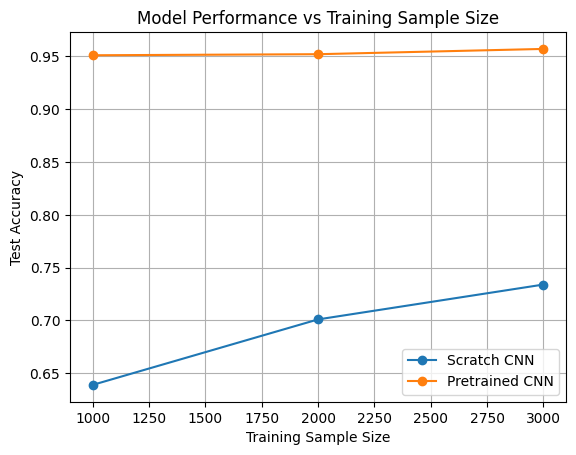

In [1]:
# Here I typed the results manually
import matplotlib.pyplot as plt

sizes = [1000, 2000, 3000]

scratch = [0.639, 0.701, 0.734]
pretrained = [0.951, 0.952, 0.957]

# Create plot
plt.figure()
plt.plot(sizes, scratch, marker='o', label='Scratch CNN')
plt.plot(sizes, pretrained, marker='o', label='Pretrained CNN')

# Labels and title
plt.xlabel('Training Sample Size')
plt.ylabel('Test Accuracy')
plt.title('Model Performance vs Training Sample Size')

# Legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()